In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
from matplotlib import rcParams
from torch.utils.data import DataLoader
from torchinfo import summary
from tqdm import tqdm

rcParams["font.sans-serif"] = ["IBM Plex Sans"]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Testing dataloader, model & loss function

In [3]:
from vinson.dataset import SeqEmbedDataset
from vinson.loss import poisson_loss
from vinson.model import BassetTrunkEmbed, CellEmbedding, EmbedModel

# Create model
embed = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = EmbedModel(trunk, embed, regression=True)

In [4]:
summary(model)

Layer (type:depth-idx)                   Param #
EmbedModel                               --
├─BassetTrunkEmbed: 1-1                  --
│    └─Sequential: 2-1                   --
│    │    └─Conv1d: 3-1                  23,100
│    │    └─BatchNorm1d: 3-2             600
│    │    └─ReLU: 3-3                    --
│    │    └─MaxPool1d: 3-4               --
│    └─ReLU: 2-2                         --
│    └─Sequential: 2-3                   --
│    │    └─Conv1d: 3-5                  660,200
│    │    └─BatchNorm1d: 3-6             400
│    │    └─ReLU: 3-7                    --
│    │    └─MaxPool1d: 3-8               --
│    └─ReLU: 2-4                         --
│    └─Sequential: 2-5                   --
│    │    └─Conv1d: 3-9                  280,200
│    │    └─BatchNorm1d: 3-10            400
│    │    └─ReLU: 3-11                   --
│    │    └─MaxPool1d: 3-12              --
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       51,400
│    └

### Simulate the loss function

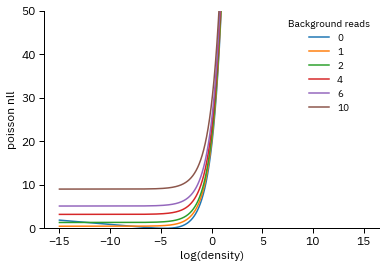

In [5]:
density = torch.tensor(0.01)
read_depth = 20e6
bg_reads = [0, 1, 2, 4, 6, 10]


input = torch.linspace(-15, 15, 10_000)

for i in bg_reads:
    pred_counts = (torch.exp(input) / 1e6 * read_depth) + i
    target_counts = density / 1e6 * read_depth

    loss = poisson_loss(pred_counts, target_counts, reduction="none")

    plt.plot(input, loss, label=f"{i}")

plt.ylim(0, 50)

plt.xlabel("log(density)")
plt.ylabel("poisson nll")


plt.legend(title="Background reads")

### Load in dataset and dataloader

In [6]:
samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL31/epoch_1/data_JUL31_pos.batch1.val.h5"
negative_samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL31/epoch_1/data_JUL31_neg.batch1.val.bed.gz"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
read_depth_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10/continious_annotation/total_cutcounts.tsv"
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"
sample_genotype_file = (
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v4/output/meta+sample_ids.tsv"
)
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v4/output/all_variants_stats.bed.gz"

# General dataset params
dataset_kwargs = dict(
    negative_samples_rate=1,
    sample_genotype_file=sample_genotype_file,
    genotype_file=genotype_file,
    reverse_complement=False,
    jitter=0,
    noise=0,
    seed=0,
)

dataset = SeqEmbedDataset(
    samples_file,
    embeddings_file,
    read_depth_file,
    fasta_file,
    negative_samples_file=negative_samples_file,
    **dataset_kwargs,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)

# Train model

To train model edit and run the following script: ```sbatch train.sh```

# Analyze, predict & interpret model

### Load in pre-trained variant model

In [7]:
pretrained_state_dict = torch.load(
    "models/data_AUG3/checkpoints/epoch=0-step=72627-val_loss=25.07.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

model.load_state_dict(pretrained_state_dict)

<All keys matched successfully>

### Predict variants (random batch)

In [8]:
batch = next(iter(dataloader))

X_seq, X_embed, indicator, density, bg, read_depth, sample_id, chrom, mid, weight = (
    batch["seq"],
    batch["embed"],
    batch["indicator"],
    batch["density"],
    batch["bg"],
    batch["read_depth"],
    batch["sample_id"],
    batch["chrom"],
    batch["mid"],
    batch["weight"],
)

In [9]:
y_ = model(X_seq, X_embed).squeeze().detach()

ps = 1e-6
pred_counts = (torch.exp(y_) / 1e6 * read_depth) + bg
pred_counts = pred_counts.detach()

target_counts = density / 1e6 * read_depth
target_counts = target_counts.detach()

bg_density = bg / read_depth * 1e6
pred_total_density = torch.exp(y_) + bg_density

loss = poisson_loss(pred_counts + ps, target_counts + ps, reduction="none")
loss *= weight

print(f"loss = {loss.mean()}")

loss = 16.061071395874023


#### Predicted vs. observed read counts

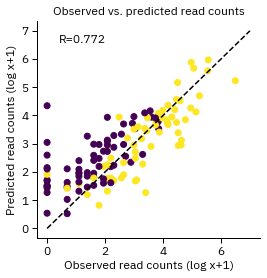

In [10]:
x = (target_counts + 1).log()
y = (pred_counts + 1).log()

plt.scatter(
    x,
    y,
    c=indicator,
)

plt.plot([0, 7], [0, 7], color="k", ls="--")

plt.xlabel("Observed read counts (log x+1)")
plt.ylabel("Predicted read counts (log x+1)")

pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted read counts")

plt.gcf().set_size_inches(4, 4)

Text(0.5, 1.0, 'Observed vs. predicted density')

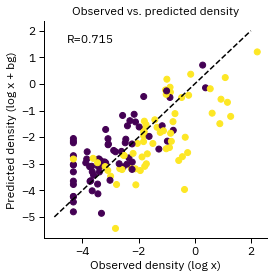

In [11]:
x = (density + 0.05).log2()
y = pred_total_density.log2()

plt.scatter(x, y, c=indicator)
plt.gcf().set_size_inches(4, 4)

plt.plot([-5, 2], [-5, 2], color="k", ls="--")

plt.xlabel("Observed density (log x)")
plt.ylabel("Predicted density (log x + bg)")


pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted density")

#### Predicted vs. observed peak densities

Text(0, 0.5, 'Peak density')

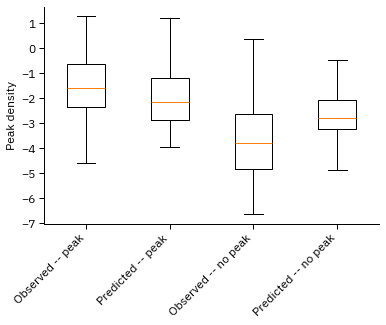

In [12]:
pred_w_peak = pred_total_density.log2()[indicator.to(bool)]
pred_wo_peak = pred_total_density.log2()[~indicator.to(bool)]


obs_w_peak = (density + 0.01).log2()[indicator.to(bool)]
obs_wo_peak = (density + 0.01).log2()[~indicator.to(bool)]

y = [
    obs_w_peak,
    pred_w_peak,
    obs_wo_peak,
    pred_wo_peak,
]

b = plt.boxplot(y, showfliers=False)

plt.xticks(
    np.arange(len(y)) + 1,
    labels=[
        "Observed -- peak",
        "Predicted -- peak",
        "Observed -- no peak",
        "Predicted -- no peak",
    ],
    rotation=45,
    ha="right",
)

plt.ylabel("Peak density")

#### Loss landscape

Text(0.5, 1.0, 'Loss landscape for batch')

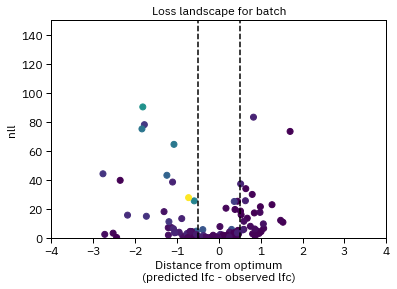

In [13]:
lfc = y_ - torch.log(density)

ax = plt.gca()

ax.scatter(lfc, loss, label="delta NLL", c=density)
ax.axvline(-0.5, color="k", ls="--")
ax.axvline(0.5, color="k", ls="--")

plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
ax.set_ylabel("nll")

ax.set_xlim(-4, 4)
ax.set_ylim(0, 150)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Loss landscape for batch")

#### Prediction error by peak density

Text(0.5, 1.0, 'Model prediction error by peak density')

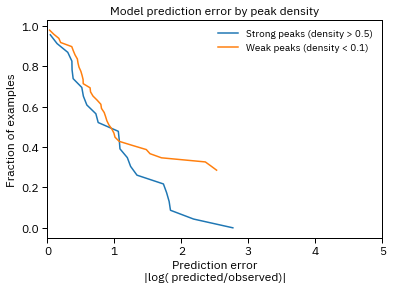

In [14]:
lfc_abs = lfc.abs()

x = lfc_abs[density > 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Strong peaks (density > 0.5)")

x = lfc_abs[density < 0.1]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Weak peaks (density < 0.1)")

plt.xlabel("Prediction error\n|log( predicted/observed)|")
plt.ylabel("Fraction of examples")

plt.legend()

plt.xlim(0, 5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Model prediction error by peak density")

### Contribution scores

In [15]:
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.model import _Exp

In [16]:
print(torch.where(y_.exp() > 0.45))

(tensor([  7,  14,  24,  31,  32,  47,  57,  67,  68,  71,  73,  80,  88,  89,
         93, 100, 107, 116]),)


In [35]:
i = 32
torch.exp(y_[i]), density[i] - bg_density[i], density[i]

(tensor(0.6379), tensor(1.8304), tensor(1.8643))

In [36]:
_X = force_strict_ohe(X_seq[i : i + 1].clone())

Y_embed = X_embed[i : i + 1].clone()

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model,
    _X,
    args=(Y_embed,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[:, 1].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model,
    _X,
    args=(Y_embed_rand,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)


tensor([0.0000e+00, 5.9605e-08, 2.9802e-08, 2.9802e-08, 8.9407e-08, 1.4901e-07,
        5.9605e-08, 5.9605e-08, 5.9605e-08, 0.0000e+00, 8.9407e-08, 8.9407e-08,
        2.9802e-08, 0.0000e+00, 2.0862e-07, 8.9407e-08, 2.9802e-08, 0.0000e+00,
        1.4901e-08, 2.9802e-08], grad_fn=<AbsBackward0>)
tensor([1.1921e-07, 0.0000e+00, 2.9802e-08, 2.9802e-08, 2.9802e-08, 5.9605e-08,
        1.4901e-08, 5.9605e-08, 2.9802e-08, 2.9802e-08, 1.1921e-07, 4.4703e-08,
        2.9802e-08, 2.9802e-08, 8.9407e-08, 8.9407e-08, 0.0000e+00, 7.4506e-08,
        2.9802e-08, 0.0000e+00], grad_fn=<AbsBackward0>)


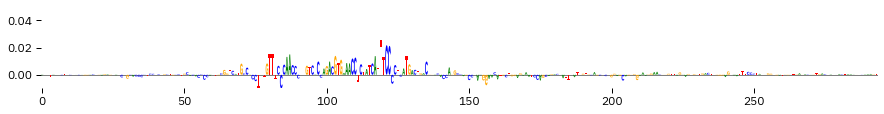

In [37]:
from tangermeme.plot import plot_logo

fig, ax = plt.subplots()
plot_logo(attrs[0][:, 550:-500], ax=ax)
ax.set_ylim(top=0.05)
fig.set_size_inches(15, 1.5)

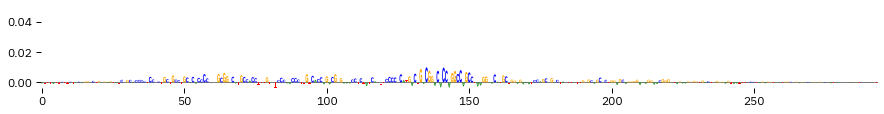

In [38]:
fig, ax = plt.subplots()
plot_logo(attrs_rand[0][:, 550:-500], ax=ax)
ax.set_ylim(top=0.05)
fig.set_size_inches(15, 1.5)

In [132]:
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise

In [133]:
Y_all = apply_pairwise(
    predict, 
    model, 
    _X, #force_strict_ohe(X_seq), #_X, 
    args=(torch.as_tensor(dataset.embeddings_df.T.values),), device="cpu", verbose=True)


0it [00:00, ?it/s]/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)
4159it [01:04, 64.74it/s]


Text(0, 0.5, 'Number of samples')

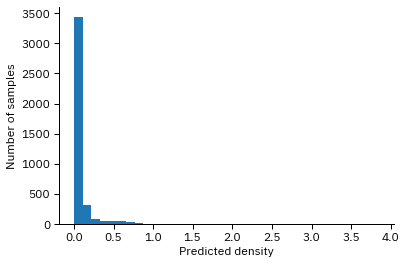

In [134]:
plt.hist(Y_all.squeeze().exp())

plt.xlabel("Predicted density")
plt.ylabel("Number of samples")

In [135]:
from openTSNE import TSNE

tsne = TSNE(
    perplexity=20,
    metric="euclidean",
    n_jobs=1,
    random_state=42,
    verbose=True,
)

embedding_train = tsne.fit(dataset.embeddings_df.T.to_numpy())

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, perplexity=20, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 60 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 5.63 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.16 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.09 seconds
===> Running optimization with exaggeration=12.00, lr=346.58 for 250 iterations...
Iteration   50, KL divergence 3.4614, 50 iterations in 7.4589 sec
Iteration  100, KL divergence 3.3986, 50 iterations in 6.4695 sec
Iteration  150, KL divergence 3.3735, 50 iterations in 6.7424 sec
Iteration  200, KL divergence 3.3629, 50 iterations in 6.9562 sec
Iteration  250, KL divergence 3.3578, 50 iterations in 6.4849 sec
   --> Time elapsed: 34.11 seconds
===> Running optimization with exaggerat

In [136]:
def zscore_normalization(series):
    return (series - series.mean()) / series.std()

Text(0.5, 0.98, 'Predicted DHS activity across cell types')

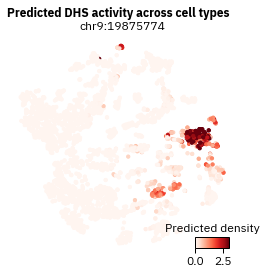

In [137]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=zscore_normalization(Y_all.squeeze().exp()), vmin=0, vmax=3, cmap="Reds")

axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Predicted density")

ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.spines[['left', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

fig.suptitle("Predicted DHS activity across cell types")



In [138]:
sample_id[i]


'AG80507'

In [139]:
k = np.argsort(Y_all.squeeze())

In [140]:
dataset.embeddings_df.columns[k][-30:]

Index(['AG80790', 'AG79956', 'AG80746', 'AG80781', 'AG80804', 'AG80765',
       'AG80401', 'AG80782', 'AG80814', 'AG80402', 'AG80803', 'AG80773',
       'AG80423', 'AG80758', 'AG80760', 'AG80443', 'AG80761', 'AG80414',
       'AG80413', 'AG80694', 'AG80444', 'AG80422', 'AG80409', 'AG80407',
       'AG80410', 'AG80421', 'AG80416', 'AG80408', 'AG80415', 'AG80420'],
      dtype='object')